# Sistem Rekomendasi Film — Content-Based Filtering & Collaborative Filtering

**Nama:** David Kurniawan
**Kelas:** Dicoding — Belajar Machine Learning Terapan
**Dataset:** [MovieLens Latest Small (`ml-latest-small`)](https://grouplens.org/datasets/movielens/latest/) — GroupLens Research

Notebook ini membangun sistem rekomendasi film *top-N* dengan dua pendekatan:

1. **Content-Based Filtering (CBF)** — TF-IDF pada genre dan *tag* pengguna, lalu *weighted cosine similarity*.
2. **Collaborative Filtering (CF)** — dua algoritma:
   * **SVD** (*matrix factorization*, library Surprise) dengan *hyperparameter tuning* `GridSearchCV`.
   * **Neural Collaborative Filtering (NeuMF)** berbasis PyTorch (GPU bila tersedia) yang dilatih dengan *implicit feedback* dan *negative sampling*.

Urutan notebook sama dengan urutan laporan: **Data Loading → Data Understanding & EDA → Data Preparation → Modeling → Evaluation → Kesimpulan**.

## 1. Setup & Import Library

Sel berikut memasang `scikit-surprise` bila belum ada, mengimpor library, menetapkan *random seed* agar hasil dapat direproduksi, dan mendeteksi perangkat komputasi (CUDA/CPU).

In [1]:
import importlib.util
import subprocess
import sys

# Pasang scikit-surprise hanya jika belum tersedia (mis. saat dijalankan di Google Colab).
if importlib.util.find_spec("surprise") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "scikit-surprise"])

In [2]:
import copy
import io
import random
import re
import time
import warnings
import zipfile
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import seaborn as sns
import torch
from IPython.display import display
from scipy import sparse
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import linear_kernel
from sklearn.preprocessing import normalize
from surprise import SVD, Dataset, Reader
from surprise.model_selection import GridSearchCV
from torch import nn

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 160)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("PyTorch :", torch.__version__)
print("Device  :", DEVICE, f"({torch.cuda.get_device_name(0)})" if DEVICE.type == "cuda" else "")

PyTorch : 2.6.0+cu124
Device  : cuda (NVIDIA GeForce RTX 4050 Laptop GPU)


In [3]:
# Struktur folder: jika notebook dijalankan dari folder `notebooks/`, root proyek adalah parent-nya.
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RAW_DIR = PROJECT_ROOT / "data" / "raw"
FIG_DIR = PROJECT_ROOT / "outputs" / "figures"
RESULT_DIR = PROJECT_ROOT / "outputs" / "results"
for folder in (RAW_DIR, FIG_DIR, RESULT_DIR):
    folder.mkdir(parents=True, exist_ok=True)

# Konstanta yang dipakai di seluruh notebook
MIN_USER_RATINGS = 20      # user dengan < 20 rating dibuang
MIN_MOVIE_RATINGS = 5      # film dengan < 5 rating dibuang
TEST_SIZE = 0.2            # 80:20 per user
RELEVANCE_THRESHOLD = 4.0  # film dianggap relevan/disukai jika rating >= 4.0
K_VALUES = (5, 10)
TOP_N = 10

## 2. Data Loading

Dataset **MovieLens Latest Small** diunduh langsung dari situs GroupLens, kemudian empat berkas CSV (`movies.csv`, `ratings.csv`, `tags.csv`, `links.csv`) diekstrak ke `data/raw/`. Jika berkas sudah ada, unduhan dilewati.

In [4]:
DATASET_URL = "https://files.grouplens.org/datasets/movielens/ml-latest-small.zip"
FILES = ["movies.csv", "ratings.csv", "tags.csv", "links.csv"]

if not all((RAW_DIR / f).exists() for f in FILES):
    response = requests.get(DATASET_URL, timeout=60)
    response.raise_for_status()
    with zipfile.ZipFile(io.BytesIO(response.content)) as archive:
        for f in FILES:
            (RAW_DIR / f).write_bytes(archive.read(f"ml-latest-small/{f}"))
    print("Dataset berhasil diunduh ke", RAW_DIR)
else:
    print("Dataset sudah tersedia di", RAW_DIR)

movies = pd.read_csv(RAW_DIR / "movies.csv")
ratings = pd.read_csv(RAW_DIR / "ratings.csv")
tags = pd.read_csv(RAW_DIR / "tags.csv")
links = pd.read_csv(RAW_DIR / "links.csv")

Dataset sudah tersedia di C:\Users\David\movie-recommendation-system-ml\data\raw


## 3. Data Understanding

### 3.1 Ukuran dan kondisi data

Langkah pertama adalah melihat jumlah baris/kolom, tipe data, *missing value*, dan duplikat pada setiap tabel.

In [5]:
tables = {"movies": movies, "ratings": ratings, "tags": tags, "links": links}
summary = pd.DataFrame(
    {
        name: {
            "baris": len(df),
            "kolom": df.shape[1],
            "missing_values": int(df.isna().sum().sum()),
            "duplikat": int(df.duplicated().sum()),
        }
        for name, df in tables.items()
    }
).T
display(summary)

for name, df in tables.items():
    print(f"\n===== {name} =====")
    df.info()

,baris,kolom,missing_values,duplikat
movies,9742,3,0,0
ratings,100836,4,0,0
tags,3683,4,0,0
links,9742,3,8,0



===== movies =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9742 entries, 0 to 9741
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   movieId  9742 non-null   int64 
 1   title    9742 non-null   object
 2   genres   9742 non-null   object
dtypes: int64(1), object(2)
memory usage: 228.5+ KB

===== ratings =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100836 entries, 0 to 100835
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   userId     100836 non-null  int64  
 1   movieId    100836 non-null  int64  
 2   rating     100836 non-null  float64
 3   timestamp  100836 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 3.1 MB

===== tags =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3683 entries, 0 to 3682
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   use

In [6]:
for name, df in tables.items():
    print(f"\n===== {name}: 5 baris pertama =====")
    display(df.head())


===== movies: 5 baris pertama =====


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy



===== ratings: 5 baris pertama =====


,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931



===== tags: 5 baris pertama =====


,userId,movieId,tag,timestamp
0,2,60756,funny,1445714994
1,2,60756,Highly quotable,1445714996
2,2,60756,will ferrell,1445714992
3,2,89774,Boxing story,1445715207
4,2,89774,MMA,1445715200



===== links: 5 baris pertama =====


,movieId,imdbId,tmdbId
0,1,114709,862.0
1,2,113497,8844.0
2,3,113228,15602.0
3,4,114885,31357.0
4,5,113041,11862.0


In [7]:
print("Missing value per kolom:")
for name, df in tables.items():
    print(f"  {name:8s}", df.isna().sum().to_dict())

n_users = ratings["userId"].nunique()
n_rated_movies = ratings["movieId"].nunique()
print(f"\nJumlah film di katalog          : {movies['movieId'].nunique():,}")
print(f"Jumlah user unik                : {n_users:,}")
print(f"Jumlah film yang pernah dirating: {n_rated_movies:,}")
print(f"Jumlah rating                   : {len(ratings):,}")
print(f"Jumlah tag                      : {len(tags):,} (pada {tags['movieId'].nunique():,} film)")
print(f"Sparsity matriks user-item      : {1 - len(ratings) / (n_users * n_rated_movies):.4%}")
print(f"Rentang waktu rating            : {pd.to_datetime(ratings['timestamp'], unit='s').min().date()}"
      f" s.d. {pd.to_datetime(ratings['timestamp'], unit='s').max().date()}")
print(f"Film tanpa genre                : {(movies['genres'] == '(no genres listed)').sum()}")
print(f"Judul film duplikat             : {movies['title'].duplicated().sum()}")
no_year = (~movies["title"].str.contains(r"\(\d{4}\)\s*$")).sum()
print(f"Film tanpa tahun pada judul     : {no_year}")

Missing value per kolom:
  movies   {'movieId': 0, 'title': 0, 'genres': 0}
  ratings  {'userId': 0, 'movieId': 0, 'rating': 0, 'timestamp': 0}
  tags     {'userId': 0, 'movieId': 0, 'tag': 0, 'timestamp': 0}
  links    {'movieId': 0, 'imdbId': 0, 'tmdbId': 8}

Jumlah film di katalog          : 9,742
Jumlah user unik                : 610
Jumlah film yang pernah dirating: 9,724
Jumlah rating                   : 100,836
Jumlah tag                      : 3,683 (pada 1,572 film)
Sparsity matriks user-item      : 98.3000%
Rentang waktu rating            : 1996-03-29 s.d. 2018-09-24
Film tanpa genre                : 34
Judul film duplikat             : 5
Film tanpa tahun pada judul     : 13


In [8]:
display(ratings[["rating"]].describe().T)
per_user = ratings.groupby("userId").size()
per_movie = ratings.groupby("movieId").size()
display(pd.DataFrame({"rating per user": per_user.describe(), "rating per film": per_movie.describe()}).T)

,count,mean,std,min,25%,50%,75%,max
rating,100836.0,3.501557,1.042529,0.5,3.0,3.5,4.0,5.0


,count,mean,std,min,25%,50%,75%,max
rating per user,610.0,165.304918,269.480584,20.0,35.0,70.5,168.0,2698.0
rating per film,9724.0,10.369807,22.401005,1.0,1.0,3.0,9.0,329.0


### 3.2 Deskripsi variabel

| Berkas | Variabel | Deskripsi |
|---|---|---|
| `movies.csv` | `movieId` | ID unik film (integer). |
| | `title` | Judul film beserta tahun rilis dalam kurung, mis. `Toy Story (1995)`. |
| | `genres` | Daftar genre yang dipisahkan `|` (20 label, termasuk `(no genres listed)`). |
| `ratings.csv` | `userId` | ID unik pengguna (anonim). |
| | `movieId` | ID film yang dirating (terhubung ke `movies.csv`). |
| | `rating` | Rating eksplisit skala 0.5–5.0 dengan kelipatan 0.5. |
| | `timestamp` | Waktu pemberian rating (detik sejak 1 Januari 1970 UTC). |
| `tags.csv` | `userId` | ID pengguna yang memberi tag. |
| | `movieId` | ID film yang diberi tag. |
| | `tag` | Label bebas buatan pengguna, mis. `pixar`, `dark hero`. |
| | `timestamp` | Waktu pemberian tag. |
| `links.csv` | `movieId` | ID film MovieLens. |
| | `imdbId` | ID film di IMDb. |
| | `tmdbId` | ID film di TMDb (8 nilai kosong). |

`links.csv` hanya berisi ID eksternal sehingga tidak dipakai dalam pemodelan.

### 3.3 Exploratory Data Analysis (EDA)

Semua grafik dibuat oleh fungsi visualisasi yang **didefinisikan langsung di notebook ini**. Notebook tidak mengimpor modul apa pun dari repositori, sehingga dapat dijalankan secara mandiri (mis. di Google Colab) dan tetap menghasilkan seluruh grafik. Setiap fungsi menggambar satu grafik, menyimpannya ke `outputs/figures/` (dipakai di laporan), lalu mengembalikan objek `Figure`.

Fungsi pendukung dan fungsi visualisasi EDA:

In [9]:
ACCENT = "#d64545"


def apply_theme() -> None:
    """Apply the shared seaborn theme. Call once before plotting so every figure matches."""
    sns.set_theme(style="whitegrid")


def _finish(fig: plt.Figure, save_path: Path | str | None) -> plt.Figure:
    """Tighten the layout and save ``fig`` to ``save_path`` (if given)."""
    fig.tight_layout()
    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=120, bbox_inches="tight")
    return fig


def _genre_lists(genres: pd.Series) -> pd.Series:
    """Split ``Action|Comedy`` strings into lists."""
    return genres.fillna("").str.split("|")


def plot_rating_distribution(
    ratings: pd.DataFrame, threshold: float = 4.0, save_path: Path | str | None = None
) -> plt.Figure:
    """Bar chart of how often each rating value (0.5–5.0) is given."""
    counts = ratings["rating"].value_counts().sort_index()
    fig, ax = plt.subplots(figsize=(8, 4))
    sns.barplot(x=counts.index.astype(str), y=counts.values, color="#3b7dd8", ax=ax)
    ax.axvline(
        list(counts.index).index(threshold) - 0.5,
        color=ACCENT,
        ls="--",
        label=f"relevan (≥ {threshold})",
    )
    ax.set(title="Distribusi rating", xlabel="Rating", ylabel="Jumlah rating")
    ax.legend()
    return _finish(fig, save_path)


def plot_genre_frequency(movies: pd.DataFrame, save_path: Path | str | None = None) -> plt.Figure:
    """Horizontal bar chart of the number of movies per genre."""
    counts = _genre_lists(movies["genres"]).explode().value_counts()
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.barplot(
        x=counts.values, y=counts.index, hue=counts.index, palette="viridis", legend=False, ax=ax
    )
    ax.set(title="Jumlah film per genre", xlabel="Jumlah film", ylabel="")
    return _finish(fig, save_path)


def plot_user_activity(ratings: pd.DataFrame, save_path: Path | str | None = None) -> plt.Figure:
    """Histogram (log x-axis) of the number of ratings per user."""
    per_user = ratings.groupby("userId").size()
    bins = np.logspace(np.log10(per_user.min()), np.log10(per_user.max()), 40)
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.hist(per_user, bins=bins, color="#2a9d8f", edgecolor="white")
    ax.set_xscale("log")
    ax.axvline(per_user.median(), color=ACCENT, ls="--", label=f"median = {per_user.median():.0f}")
    ax.set(
        title="Jumlah rating per user", xlabel="Rating per user (skala log)", ylabel="Jumlah user"
    )
    ax.legend()
    return _finish(fig, save_path)


def plot_long_tail(ratings: pd.DataFrame, save_path: Path | str | None = None) -> plt.Figure:
    """Movie popularity curve highlighting the head that receives 50% of all ratings."""
    per_movie = ratings.groupby("movieId").size().sort_values(ascending=False).to_numpy()
    cumulative = per_movie.cumsum() / per_movie.sum()
    head = int(np.searchsorted(cumulative, 0.5)) + 1
    ranks = np.arange(1, len(per_movie) + 1)

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(ranks, per_movie, color="#264653")
    ax.fill_between(
        ranks[:head],
        per_movie[:head],
        color="#e9c46a",
        alpha=0.6,
        label=f"{head} film teratas = 50% rating",
    )
    ax.set_yscale("log")
    ax.set(
        title="Popularitas film (long tail)",
        xlabel="Peringkat film",
        ylabel="Jumlah rating (skala log)",
    )
    ax.legend()
    return _finish(fig, save_path)


def plot_ratings_per_year(ratings: pd.DataFrame, save_path: Path | str | None = None) -> plt.Figure:
    """Number of ratings (bars) and mean rating (line) per calendar year."""
    years = pd.to_datetime(ratings["timestamp"], unit="s").dt.year
    yearly = ratings.groupby(years)["rating"].agg(["size", "mean"])
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.bar(yearly.index, yearly["size"], color="#8ab17d")
    ax.set(title="Jumlah rating per tahun", xlabel="Tahun", ylabel="Jumlah rating")
    ax2 = ax.twinx()
    ax2.plot(yearly.index, yearly["mean"], color=ACCENT, marker="o")
    ax2.set_ylabel("Rata-rata rating", color=ACCENT)
    ax2.grid(False)
    return _finish(fig, save_path)


def plot_top_tags(
    tags: pd.DataFrame, top_n: int = 20, save_path: Path | str | None = None
) -> plt.Figure:
    """Most frequent tags (lower-cased and stripped)."""
    counts = tags["tag"].str.lower().str.strip().value_counts().head(top_n)
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.barplot(
        x=counts.values, y=counts.index, hue=counts.index, palette="mako", legend=False, ax=ax
    )
    ax.set(title=f"{top_n} tag terpopuler", xlabel="Frekuensi", ylabel="")
    return _finish(fig, save_path)


def plot_genre_ratings(
    movies: pd.DataFrame,
    ratings: pd.DataFrame,
    min_ratings: int = 5,
    save_path: Path | str | None = None,
) -> plt.Figure:
    """Box plot of per-movie mean rating by genre, for movies with ``>= min_ratings``."""
    stats = ratings.groupby("movieId")["rating"].agg(["mean", "size"]).reset_index()
    stats = stats[stats["size"] >= min_ratings].merge(movies[["movieId", "genres"]], on="movieId")
    exploded = stats.assign(genre=_genre_lists(stats["genres"])).explode("genre")
    order = exploded.groupby("genre")["mean"].median().sort_values(ascending=False).index
    fig, ax = plt.subplots(figsize=(9, 6))
    sns.boxplot(
        data=exploded, x="mean", y="genre", order=order, color="#90be6d", fliersize=2, ax=ax
    )
    ax.set(
        title=f"Rata-rata rating film per genre (film dengan ≥ {min_ratings} rating)",
        xlabel="Rata-rata rating film",
        ylabel="",
    )
    return _finish(fig, save_path)


def plot_sparsity(
    ratings: pd.DataFrame, size: int = 100, save_path: Path | str | None = None
) -> plt.Figure:
    """Filled cells of the ``size`` most active users × ``size`` most rated movies."""
    top_users = ratings["userId"].value_counts().index[:size]
    top_movies = ratings["movieId"].value_counts().index[:size]
    block = (
        ratings[ratings["userId"].isin(top_users) & ratings["movieId"].isin(top_movies)]
        .pivot_table(index="userId", columns="movieId", values="rating")
        .reindex(index=top_users, columns=top_movies)
    )
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.imshow(block.notna(), cmap="Greys", aspect="auto", interpolation="nearest")
    ax.set(
        title=f"Matriks user-item: {size} user teraktif × {size} film terpopuler\n"
        "(sel hitam = ada rating)",
        xlabel="Film",
        ylabel="User",
    )
    ax.grid(False)
    return _finish(fig, save_path)


apply_theme()

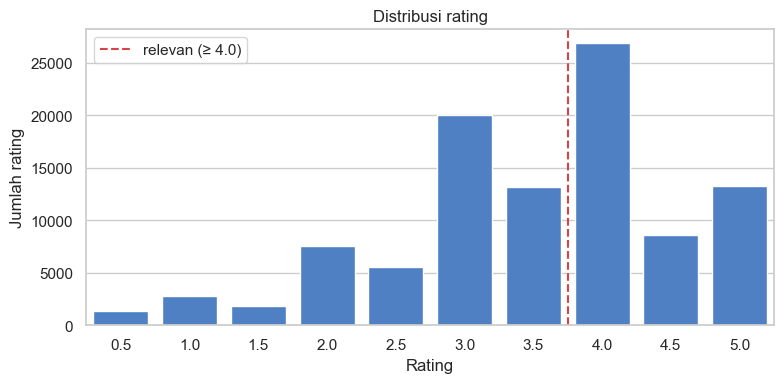

Rata-rata rating: 3.50 | median: 3.5
Proporsi rating >= 4.0: 48.2%


In [10]:
plot_rating_distribution(ratings, threshold=RELEVANCE_THRESHOLD, save_path=FIG_DIR / "01_rating_distribution.png")
plt.show()
print(f"Rata-rata rating: {ratings['rating'].mean():.2f} | median: {ratings['rating'].median()}")
print(f"Proporsi rating >= 4.0: {(ratings['rating'] >= RELEVANCE_THRESHOLD).mean():.1%}")

**Insight:** rating condong ke nilai tinggi — nilai paling sering adalah 4.0, disusul 3.0 dan 5.0, dengan rata-rata ±3.5. Pengguna juga lebih sering memberi angka bulat daripada setengah. Sekitar setengah rating bernilai ≥ 4.0, sehingga ambang **4.0** masuk akal untuk mendefinisikan film yang *relevan/disukai* saat evaluasi.

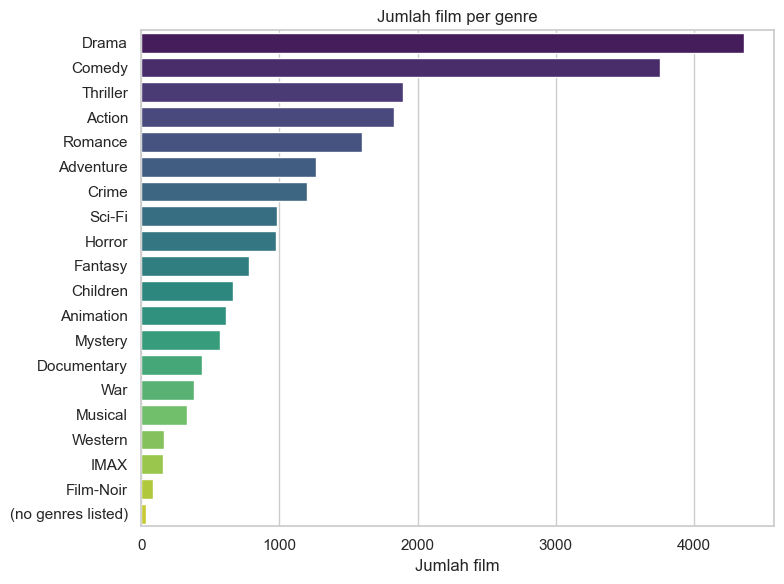

Rata-rata jumlah genre per film: 2.27


In [11]:
plot_genre_frequency(movies, save_path=FIG_DIR / "02_genre_frequency.png")
plt.show()
print("Rata-rata jumlah genre per film:", round(movies["genres"].str.split("|").str.len().mean(), 2))

**Insight:** *Drama* dan *Comedy* mendominasi katalog, sedangkan *Film-Noir*, *IMAX*, dan `(no genres listed)` sangat jarang. Satu film rata-rata punya lebih dari dua genre. Genre umum seperti Drama kurang membedakan satu film dari film lain, sehingga pembobotan **TF-IDF** (memberi bobot kecil pada genre umum) tepat untuk *content-based filtering*.

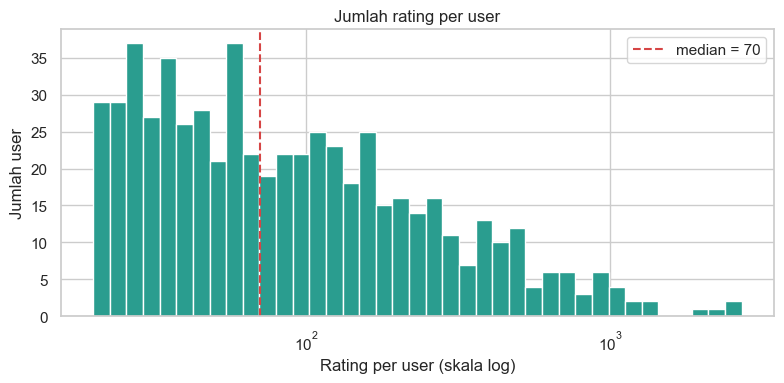

Median rating per user: 70.5 | maksimum: 2,698


In [12]:
plot_user_activity(ratings, save_path=FIG_DIR / "03_user_activity.png")
plt.show()
print(f"Median rating per user: {per_user.median():.1f} | maksimum: {per_user.max():,}")

**Insight:** setiap user memiliki minimal 20 rating (sesuai kebijakan GroupLens), tetapi distribusinya sangat miring ke kanan: median sekitar 70 rating, sementara user paling aktif memberi lebih dari 2.600 rating. Pembagian *train/test* dilakukan **per user** agar setiap user tetap terwakili di kedua set.

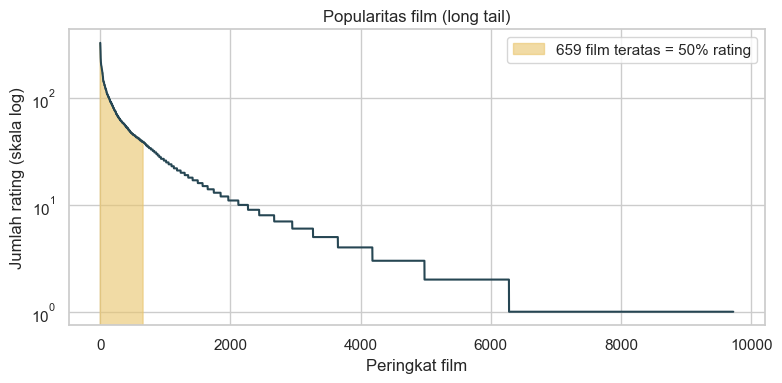

659 film (6.8% film yang dirating) menerima 50% seluruh rating.
Film dengan hanya 1 rating: 3,446 (35.4%)
Film dengan < 5 rating: 6,074


In [13]:
plot_long_tail(ratings, save_path=FIG_DIR / "04_long_tail.png")
plt.show()
sorted_counts = per_movie.sort_values(ascending=False).to_numpy()
head = int(np.searchsorted(sorted_counts.cumsum() / sorted_counts.sum(), 0.5)) + 1
print(f"{head} film ({head / len(sorted_counts):.1%} film yang dirating) menerima 50% seluruh rating.")
print(f"Film dengan hanya 1 rating: {(per_movie == 1).sum():,} ({(per_movie == 1).mean():.1%})")
print(f"Film dengan < {MIN_MOVIE_RATINGS} rating: {(per_movie < MIN_MOVIE_RATINGS).sum():,}")

**Insight:** pola **long tail** terlihat jelas — sebagian kecil film populer menerima separuh rating, sedangkan lebih dari sepertiga film hanya punya satu rating. Film dengan sangat sedikit rating tidak memberi sinyal kolaboratif yang cukup, sehingga film dengan < 5 rating akan difilter pada tahap *data preparation*.

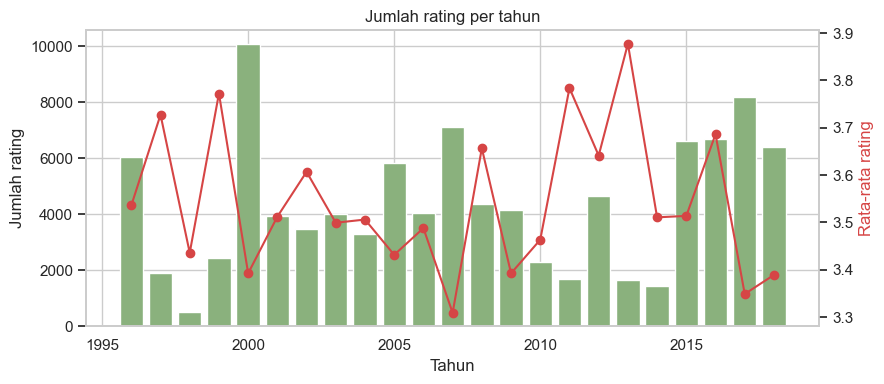

Rata-rata rating tahunan: 3.31 – 3.88


In [14]:
plot_ratings_per_year(ratings, save_path=FIG_DIR / "05_ratings_per_year.png")
plt.show()
yearly_mean = ratings.groupby(pd.to_datetime(ratings["timestamp"], unit="s").dt.year)["rating"].mean()
print(f"Rata-rata rating tahunan: {yearly_mean.min():.2f} – {yearly_mean.max():.2f}")

**Insight:** aktivitas rating tidak merata antartahun (ada lonjakan pada beberapa tahun karena segelintir user sangat aktif), dan rata-rata rating per tahun berfluktuasi sekitar 3.3–3.9. Karena pola waktu ini tidak stabil, pembagian data dilakukan secara acak per user, bukan berdasarkan waktu.

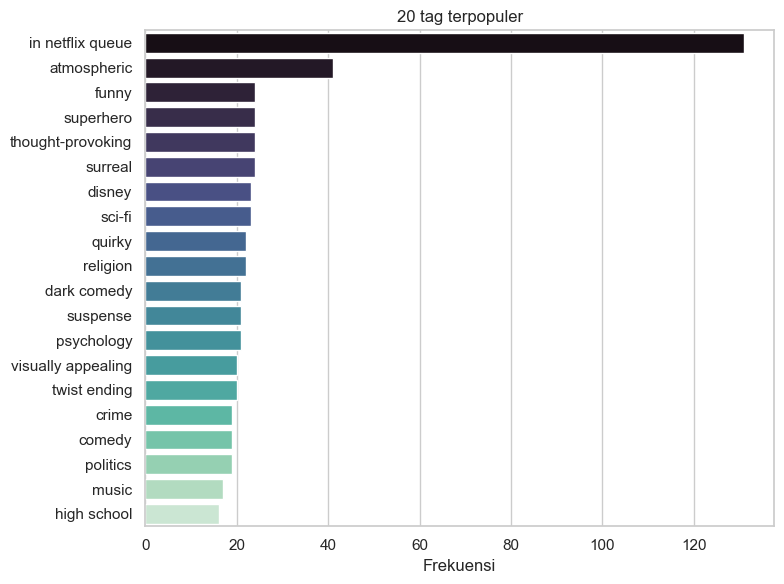

Film yang memiliki tag: 1,572 dari 9,742 (16.1%)


In [15]:
plot_top_tags(tags, top_n=20, save_path=FIG_DIR / "06_top_tags.png")
plt.show()
tagged_share = movies["movieId"].isin(tags["movieId"]).mean()
print(f"Film yang memiliki tag: {tags['movieId'].nunique():,} dari {len(movies):,} ({tagged_share:.1%})")

**Insight:** tag berisi deskripsi yang kaya makna (*atmospheric*, *superhero*, *thought-provoking*, *disney*, *twist ending*, dll.), tetapi hanya sekitar 16% film yang memiliki tag. Tag terpopuler *in netflix queue* sebenarnya penanda "ingin ditonton" dan bukan deskripsi konten, sehingga menjadi *noise* kecil yang bobotnya diredam oleh IDF. Karena itu genre dan tag akan dibobot secara **terpisah**: film tanpa tag tetap bisa direkomendasikan lewat genre, sedangkan film dengan tag mendapat sinyal tambahan.

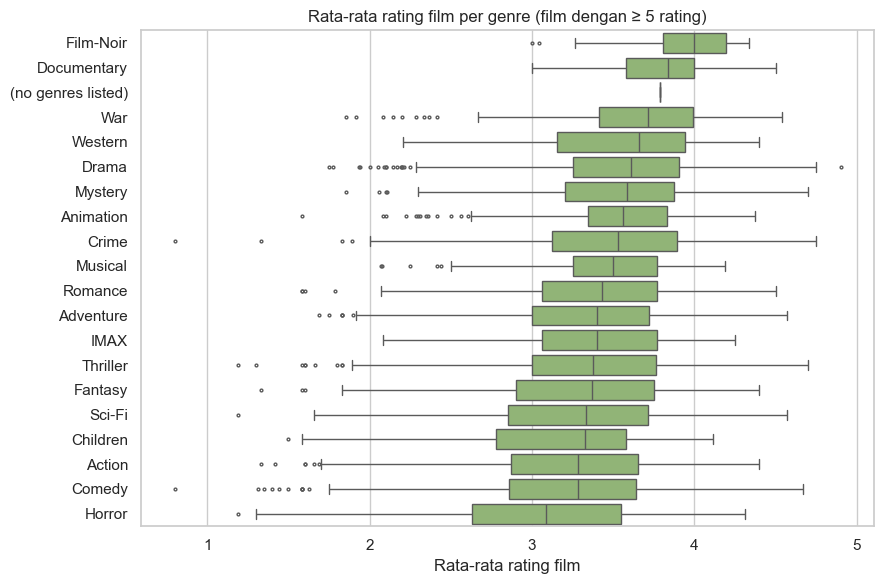

In [16]:
plot_genre_ratings(movies, ratings, min_ratings=MIN_MOVIE_RATINGS, save_path=FIG_DIR / "07_genre_ratings.png")
plt.show()

**Insight:** *Film-Noir*, *Documentary*, dan *War* memiliki median rating film tertinggi, sedangkan *Horror* paling rendah, disusul *Action*, *Comedy*, dan *Children*. Selisih antargenre tidak besar dibanding sebaran di dalam genre, jadi genre saja tidak cukup untuk memprediksi preferensi — pola kolaboratif antar-user tetap diperlukan.

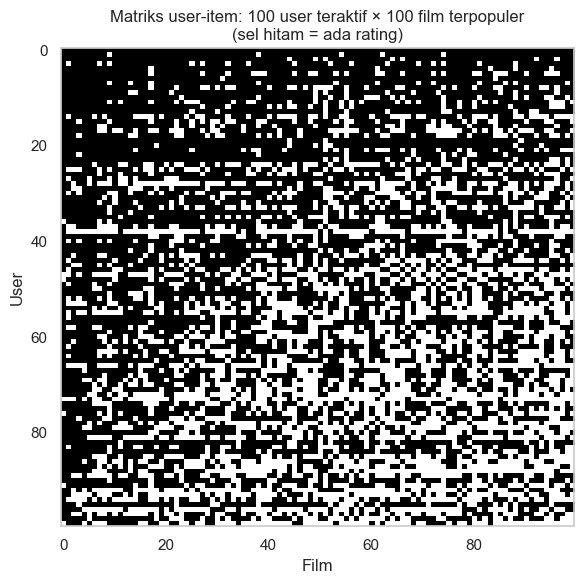

Kepadatan blok terpadat : 62.4%
Kepadatan seluruh matriks: 1.70%


In [17]:
plot_sparsity(ratings, size=100, save_path=FIG_DIR / "08_sparsity.png")
plt.show()
top_users = ratings["userId"].value_counts().index[:100]
top_movies = ratings["movieId"].value_counts().index[:100]
block_density = len(ratings[ratings["userId"].isin(top_users) & ratings["movieId"].isin(top_movies)]) / 100**2
print(f"Kepadatan blok terpadat : {block_density:.1%}")
print(f"Kepadatan seluruh matriks: {len(ratings) / (n_users * n_rated_movies):.2%}")

**Insight:** bahkan pada blok user teraktif × film terpopuler masih banyak sel kosong, dan kepadatan seluruh matriks user-item hanya sekitar 1.7% (**sparsity ± 98.3%**). Kondisi ini adalah alasan utama memakai *matrix factorization* (SVD) dan *embedding* (NeuMF): keduanya mempelajari representasi laten berdimensi rendah yang dapat menggeneralisasi ke pasangan user-film yang belum pernah diamati.

## 4. Data Preparation

Tahapan dilakukan berurutan sebagai berikut (urutan sama dengan laporan):

1. Membersihkan data film — mengganti `(no genres listed)` dengan `Unknown`, memecah genre menjadi list, mengekstrak tahun.
2. Membersihkan data rating — validasi rentang, hapus duplikat user-film, konversi `timestamp` → `datetime`.
3. Membersihkan dan menormalisasi tag, lalu menggabungkannya per film.
4. Menyusun fitur konten (token genre + tag) untuk CBF.
5. Memfilter *cold-start* user dan film.
6. Membagi data *train/test* 80:20 per user.
7. *Encoding* `userId`/`movieId` ke indeks berurutan dan membangun matriks user-item.

### 4.1 Membersihkan data film

In [18]:
movies_clean = movies.drop_duplicates(subset="movieId").copy()
movies_clean["title"] = movies_clean["title"].str.strip()
movies_clean["genres"] = movies_clean["genres"].replace("(no genres listed)", "Unknown")
movies_clean["genre_list"] = movies_clean["genres"].str.split("|")
movies_clean["year"] = pd.to_numeric(
    movies_clean["title"].str.extract(r"\((\d{4})\)\s*$")[0], errors="coerce"
).astype("Int64")

print("Film dengan genre 'Unknown':", (movies_clean["genres"] == "Unknown").sum())
print("Film tanpa tahun           :", movies_clean["year"].isna().sum())
display(movies_clean.head())

Film dengan genre 'Unknown': 34
Film tanpa tahun           : 13


,movieId,title,genres,genre_list,year
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,"[Adventure, Animation, Children, Comedy, Fantasy]",1995
1,2,Jumanji (1995),Adventure|Children|Fantasy,"[Adventure, Children, Fantasy]",1995
2,3,Grumpier Old Men (1995),Comedy|Romance,"[Comedy, Romance]",1995
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance,"[Comedy, Drama, Romance]",1995
4,5,Father of the Bride Part II (1995),Comedy,[Comedy],1995


### 4.2 Membersihkan data rating

In [19]:
ratings_clean = ratings.dropna(subset=["userId", "movieId", "rating"]).copy()
ratings_clean = ratings_clean[ratings_clean["rating"].between(0.5, 5.0)]
ratings_clean = (
    ratings_clean.sort_values("timestamp")
    .drop_duplicates(subset=["userId", "movieId"], keep="last")
    .sort_values(["userId", "movieId"])
    .reset_index(drop=True)
)
ratings_clean["datetime"] = pd.to_datetime(ratings_clean["timestamp"], unit="s")
print(f"Rating sebelum: {len(ratings):,} | sesudah: {len(ratings_clean):,}")
display(ratings_clean.head())

Rating sebelum: 100,836 | sesudah: 100,836


,userId,movieId,rating,timestamp,datetime
0,1,1,4.0,964982703,2000-07-30 18:45:03
1,1,3,4.0,964981247,2000-07-30 18:20:47
2,1,6,4.0,964982224,2000-07-30 18:37:04
3,1,47,5.0,964983815,2000-07-30 19:03:35
4,1,50,5.0,964982931,2000-07-30 18:48:51


### 4.3 Membersihkan tag dan menggabungkannya per film

Tag diubah ke huruf kecil, karakter non-alfanumerik diganti spasi (`"Sci-Fi"` → `"sci fi"`), tag kosong dibuang, dan pasangan (film, tag) yang sama dihapus agar satu tag tidak terhitung berkali-kali hanya karena diberikan oleh beberapa user.

In [20]:
def normalize_text(text):
    return re.sub(r"[^a-z0-9]+", " ", str(text).lower()).strip()


tags_clean = tags.dropna(subset=["tag"]).copy()
tags_clean["tag_clean"] = tags_clean["tag"].map(normalize_text)
tags_clean = tags_clean[tags_clean["tag_clean"] != ""]
tags_clean = tags_clean.drop_duplicates(subset=["movieId", "tag_clean"]).reset_index(drop=True)

tag_docs = tags_clean.groupby("movieId")["tag_clean"].apply(" ".join).rename("tags")
print(f"Tag sebelum: {len(tags):,} | sesudah normalisasi & deduplikasi: {len(tags_clean):,}")
display(tag_docs.head())

Tag sebelum: 3,683 | sesudah normalisasi & deduplikasi: 3,569


movieId
1                                       pixar fun
2    fantasy magic board game robin williams game
3                                       moldy old
5                                pregnancy remake
7                                          remake
Name: tags, dtype: object

### 4.4 Menyusun fitur konten untuk Content-Based Filtering

Setiap genre dijadikan **satu token** (`Sci-Fi` → `scifi`, `Film-Noir` → `filmnoir`) agar tidak terpecah menjadi dua kata. Tag hasil agregasi digabungkan ke tabel film; film tanpa tag diisi string kosong.

In [21]:
def genre_token(genre):
    return normalize_text(genre).replace(" ", "")


movies_content = movies_clean.merge(tag_docs, on="movieId", how="left")
movies_content["tags"] = movies_content["tags"].fillna("")
movies_content["genre_tokens"] = movies_content["genre_list"].map(
    lambda genres: " ".join(genre_token(g) for g in genres)
)
movies_content["content"] = (movies_content["genre_tokens"] + " " + movies_content["tags"]).str.strip()
display(movies_content[["movieId", "title", "genre_tokens", "tags"]].head())

,movieId,title,genre_tokens,tags
0,1,Toy Story (1995),adventure animation children comedy fantasy,pixar fun
1,2,Jumanji (1995),adventure children fantasy,fantasy magic board game robin williams game
2,3,Grumpier Old Men (1995),comedy romance,moldy old
3,4,Waiting to Exhale (1995),comedy drama romance,
4,5,Father of the Bride Part II (1995),comedy,pregnancy remake


### 4.5 Filter cold-start user dan film

User dengan < 20 rating dan film dengan < 5 rating dibuang. Filter diulang sampai stabil karena membuang film bisa membuat user turun di bawah ambang (dan sebaliknya).

In [22]:
def filter_cold_start(df, min_user=MIN_USER_RATINGS, min_movie=MIN_MOVIE_RATINGS, max_iter=10):
    for _ in range(max_iter):
        before = len(df)
        df = df[df["movieId"].map(df["movieId"].value_counts()) >= min_movie]
        df = df[df["userId"].map(df["userId"].value_counts()) >= min_user]
        if len(df) == before:
            break
    return df.reset_index(drop=True)


ratings_filtered = filter_cold_start(ratings_clean)
print(f"Rating : {len(ratings_clean):,} -> {len(ratings_filtered):,}")
print(f"User   : {ratings_clean['userId'].nunique():,} -> {ratings_filtered['userId'].nunique():,}")
print(f"Film   : {ratings_clean['movieId'].nunique():,} -> {ratings_filtered['movieId'].nunique():,}")

Rating : 100,836 -> 90,109
User   : 610 -> 602
Film   : 9,724 -> 3,643


### 4.6 Train/test split 80:20 per user

Rating setiap user diacak lalu 20% dijadikan data uji. Minimal satu rating tiap user selalu tetap di data latih sehingga semua user di data uji punya representasi di model. Film di data uji yang tidak pernah muncul di data latih dibuang, karena model kolaboratif tidak dapat menilainya.

In [23]:
def split_by_user(df, test_size=TEST_SIZE, seed=SEED):
    rng = np.random.default_rng(seed)
    shuffled = df.iloc[rng.permutation(len(df))]
    rank = shuffled.groupby("userId").cumcount()
    n_user = shuffled["userId"].map(shuffled["userId"].value_counts())
    is_test = rank < np.floor(n_user * test_size).clip(upper=n_user - 1)
    return (shuffled[~is_test].sort_index().reset_index(drop=True),
            shuffled[is_test].sort_index().reset_index(drop=True))


train_df, test_df = split_by_user(ratings_filtered)
test_df = test_df[test_df["movieId"].isin(train_df["movieId"])].reset_index(drop=True)
print(f"Train: {len(train_df):,} rating | Test: {len(test_df):,} rating")
print(f"User di train: {train_df['userId'].nunique()} | di test: {test_df['userId'].nunique()}")
print(f"Rating relevan (>= {RELEVANCE_THRESHOLD}) di test: {(test_df['rating'] >= RELEVANCE_THRESHOLD).sum():,}")

Train: 72,300 rating | Test: 17,809 rating
User di train: 602 | di test: 602
Rating relevan (>= 4.0) di test: 8,876


### 4.7 Encoding ID dan matriks user-item

`userId` dan `movieId` dipetakan ke indeks 0..n-1 agar bisa dipakai sebagai indeks *embedding* PyTorch dan baris/kolom matriks. Himpunan film di data latih menjadi **kandidat rekomendasi** yang sama untuk semua model sehingga perbandingan adil.

In [24]:
user_ids = np.sort(train_df["userId"].unique())
item_ids = np.sort(train_df["movieId"].unique())
user_to_idx = {u: i for i, u in enumerate(user_ids)}
item_to_idx = {m: i for i, m in enumerate(item_ids)}
n_users, n_items = len(user_ids), len(item_ids)

train_u = train_df["userId"].map(user_to_idx).to_numpy()
train_i = train_df["movieId"].map(item_to_idx).to_numpy()
user_item = sparse.csr_matrix(
    (train_df["rating"].to_numpy(dtype=np.float32), (train_u, train_i)), shape=(n_users, n_items)
)
print(f"Matriks user-item (train): {user_item.shape} | terisi: {user_item.nnz:,} | "
      f"sparsity: {1 - user_item.nnz / (n_users * n_items):.2%}")

Matriks user-item (train): (602, 3643) | terisi: 72,300 | sparsity: 96.70%


## 5. Modeling

Semua model menghasilkan **matriks skor `[n_users × n_items]`**. Rekomendasi *top-N* untuk seorang user adalah N film dengan skor tertinggi yang **belum pernah ia rating** di data latih. Fungsi bantu berikut dipakai bersama oleh semua model.

In [25]:
def top_n_from_scores(user_id, score_row, n=TOP_N, score_name="score"):
    scores = score_row.astype(np.float64).copy()
    seen = train_df.loc[train_df["userId"] == user_id, "movieId"].map(item_to_idx)
    scores[seen.to_numpy()] = -np.inf
    top = np.argsort(-scores, kind="stable")[:n]
    out = pd.DataFrame({"movieId": item_ids[top], score_name: scores[top].round(4)})
    return out.merge(movies_clean[["movieId", "title", "genres"]], on="movieId")[
        ["movieId", "title", "genres", score_name]
    ]


def user_history(user_id, n=10):
    hist = train_df[train_df["userId"] == user_id].sort_values(["rating", "timestamp"], ascending=False)
    return hist.head(n).merge(movies_clean[["movieId", "title", "genres"]], on="movieId")[
        ["title", "genres", "rating"]
    ]


SAMPLE_USER = int(user_ids[0])
print(f"Contoh user: {SAMPLE_USER} — 10 film dengan rating tertinggi di data latih:")
display(user_history(SAMPLE_USER))

Contoh user: 1 — 10 film dengan rating tertinggi di data latih:


,title,genres,rating
0,Tombstone (1993),Action|Drama|Western,5.0
1,Canadian Bacon (1995),Comedy|War,5.0
2,Pink Floyd: The Wall (1982),Drama|Musical,5.0
3,"Messenger: The Story of Joan of Arc, The (1999)",Drama|War,5.0
4,Rob Roy (1995),Action|Drama|Romance|War,5.0
5,Henry V (1989),Action|Drama|Romance|War,5.0
6,Schindler's List (1993),Drama|War,5.0
7,M*A*S*H (a.k.a. MASH) (1970),Comedy|Drama|War,5.0
8,"Green Mile, The (1999)",Crime|Drama,5.0
9,Enemy of the State (1998),Action|Thriller,5.0


### 5.1 Content-Based Filtering — TF-IDF + weighted cosine similarity

**Cara kerja**

1. **TF-IDF genre** — 20 token genre divektorisasi dengan TF-IDF sehingga genre langka (mis. `filmnoir`) berbobot lebih besar daripada genre umum (`drama`).
2. **TF-IDF tag** — tag divektorisasi dengan unigram + bigram (`min_df=2`, maksimal 5.000 fitur).
3. Kedua blok dinormalisasi L2, dikalikan `√w` lalu digabung. Hasil kali titik dua baris sama dengan
   $\text{sim}(a,b) = w \cdot \cos(\text{genre}_a,\text{genre}_b) + (1-w)\cdot\cos(\text{tag}_a,\text{tag}_b)$ dengan $w = 0.5$.

Genre dan tag dipisah karena jika digabung dalam satu dokumen, film yang tagnya banyak akan "menenggelamkan" genre, sehingga *Toy Story 2* malah kalah mirip dibanding film yang hanya kebetulan bergenre sama.

In [26]:
TOKEN_PATTERN = r"(?u)\b\w+\b"
GENRE_WEIGHT = 0.5

genre_vectorizer = TfidfVectorizer(token_pattern=TOKEN_PATTERN)
genre_tfidf = genre_vectorizer.fit_transform(movies_content["genre_tokens"])

tag_vectorizer = TfidfVectorizer(ngram_range=(1, 2), min_df=2, max_features=5000, token_pattern=TOKEN_PATTERN)
tag_tfidf = tag_vectorizer.fit_transform(movies_content["tags"])

content_matrix = sparse.hstack(
    [np.sqrt(GENRE_WEIGHT) * normalize(genre_tfidf), np.sqrt(1 - GENRE_WEIGHT) * normalize(tag_tfidf)]
).tocsr()

print("Ukuran TF-IDF genre :", genre_tfidf.shape)
print("Ukuran TF-IDF tag   :", tag_tfidf.shape)
print("Matriks konten      :", content_matrix.shape)
display(
    pd.DataFrame(genre_tfidf[:5].toarray(), columns=genre_vectorizer.get_feature_names_out(),
                 index=movies_content["title"][:5]).round(2)
)

Ukuran TF-IDF genre : (9742, 20)
Ukuran TF-IDF tag   : (9742, 1114)
Matriks konten      : (9742, 1134)


,action,adventure,animation,children,comedy,crime,documentary,drama,fantasy,filmnoir,horror,imax,musical,mystery,romance,scifi,thriller,unknown,war,western
title,,,,,,,,,,,,,,,,,,,,
Toy Story (1995),0.0,0.42,0.52,0.50,0.27,0.0,0.0,0.00,0.48,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0
Jumanji (1995),0.0,0.51,0.00,0.62,0.00,0.0,0.0,0.00,0.59,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0
Grumpier Old Men (1995),0.0,0.00,0.00,0.00,0.57,0.0,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.82,0.0,0.0,0.0,0.0,0.0
Waiting to Exhale (1995),0.0,0.00,0.00,0.00,0.51,0.0,0.0,0.47,0.00,0.0,0.0,0.0,0.0,0.0,0.73,0.0,0.0,0.0,0.0,0.0
Father of the Bride Part II (1995),0.0,0.00,0.00,0.00,1.00,0.0,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0


Fungsi visualisasi untuk *heatmap* similarity:

In [27]:
def plot_similarity_heatmap(
    similarity: pd.DataFrame, save_path: Path | str | None = None
) -> plt.Figure:
    """Annotated heatmap of a square movie × movie similarity DataFrame."""
    fig, ax = plt.subplots(figsize=(7, 5))
    sns.heatmap(similarity, annot=True, fmt=".2f", cmap="rocket_r", vmin=0, vmax=1, ax=ax)
    ax.set_title("Weighted cosine similarity antar film")
    return _finish(fig, save_path)

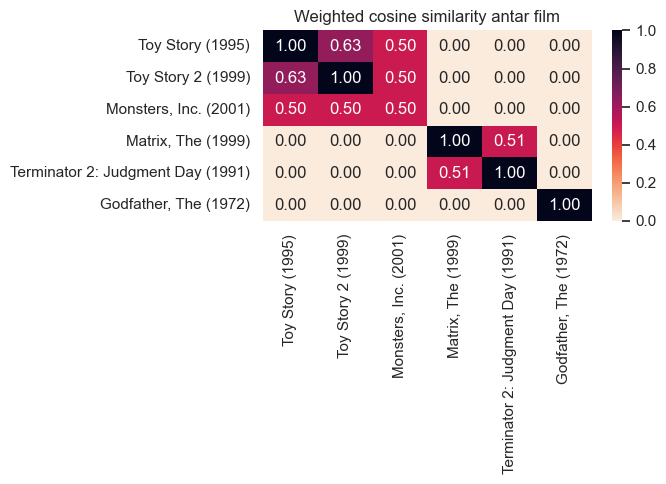

In [28]:
# Contoh matriks similarity untuk beberapa film
sample_titles = ["Toy Story (1995)", "Toy Story 2 (1999)", "Monsters, Inc. (2001)",
                 "Matrix, The (1999)", "Terminator 2: Judgment Day (1991)", "Godfather, The (1972)"]
rows = [movies_content.index[movies_content["title"] == t][0] for t in sample_titles]
sim_sample = pd.DataFrame(linear_kernel(content_matrix[rows]), index=sample_titles, columns=sample_titles)
plot_similarity_heatmap(sim_sample, save_path=FIG_DIR / "09_cbf_similarity_heatmap.png")
plt.show()

**Catatan:** *Toy Story* dan *Toy Story 2* bergenre identik **dan** berbagi tag `pixar`, sehingga skornya (0.63) lebih tinggi daripada *Monsters, Inc.* yang hanya berbagi genre (0.50). *Monsters, Inc.* tidak memiliki tag, jadi skor maksimumnya 0.5 — bahkan terhadap dirinya sendiri — karena komponen tag bernilai nol. Hal ini tidak mengubah urutan rekomendasi, karena semua kandidat dibandingkan terhadap film acuan yang sama.

In [29]:
movie_popularity = movies_content["movieId"].map(ratings_clean["movieId"].value_counts()).fillna(0).to_numpy()
title_to_row = pd.Series(movies_content.index, index=movies_content["title"].str.lower())
title_to_row = title_to_row[~title_to_row.index.duplicated()]


def recommend_similar_movies(title, top_n=TOP_N):
    # Top-N film paling mirip dengan `title`; skor sama diurutkan berdasarkan popularitas.
    key = title.strip().lower()
    if key not in title_to_row.index:
        matches = movies_content[movies_content["title"].str.lower().str.contains(key, regex=False)]
        if matches.empty:
            raise ValueError(f"Film '{title}' tidak ditemukan.")
        key = matches.iloc[0]["title"].lower()
    row = title_to_row[key]
    scores = linear_kernel(content_matrix[row], content_matrix).ravel()
    scores[row] = -np.inf
    top = np.lexsort((-movie_popularity, -np.round(scores, 6)))[:top_n]
    result = movies_content.loc[top, ["movieId", "title", "genres"]].copy()
    result["similarity"] = scores[top].round(4)
    return result.reset_index(drop=True)


for query in ["Toy Story (1995)", "Matrix, The (1999)", "Godfather, The (1972)"]:
    ref = movies_content.loc[title_to_row[query.lower()]]
    print(f"\nTop-{TOP_N} film mirip '{query}'  | genre: {ref['genres']} | tag: {ref['tags'][:80]}")
    display(recommend_similar_movies(query))


Top-10 film mirip 'Toy Story (1995)'  | genre: Adventure|Animation|Children|Comedy|Fantasy | tag: pixar fun


,movieId,title,genres,similarity
0,2355,"Bug's Life, A (1998)",Adventure|Animation|Children|Comedy,0.7984
1,3114,Toy Story 2 (1999),Adventure|Animation|Children|Comedy|Fantasy,0.6295
2,108932,The Lego Movie (2014),Action|Adventure|Animation|Children|Comedy|Fan...,0.6016
3,68954,Up (2009),Adventure|Animation|Children|Drama,0.5035
4,4886,"Monsters, Inc. (2001)",Adventure|Animation|Children|Comedy|Fantasy,0.5000
5,2294,Antz (1998),Adventure|Animation|Children|Comedy|Fantasy,0.5000
6,4016,"Emperor's New Groove, The (2000)",Adventure|Animation|Children|Comedy|Fantasy,0.5000
7,53121,Shrek the Third (2007),Adventure|Animation|Children|Comedy|Fantasy,0.5000
8,166461,Moana (2016),Adventure|Animation|Children|Comedy|Fantasy,0.5000
9,3754,"Adventures of Rocky and Bullwinkle, The (2000)",Adventure|Animation|Children|Comedy|Fantasy,0.5000



Top-10 film mirip 'Matrix, The (1999)'  | genre: Action|Sci-Fi|Thriller | tag: martial arts sci fi alternate universe philosophy post apocalyptic


,movieId,title,genres,similarity
0,3527,Predator (1987),Action|Sci-Fi|Thriller,0.5925
1,1240,"Terminator, The (1984)",Action|Sci-Fi|Thriller,0.5903
2,541,Blade Runner (1982),Action|Sci-Fi|Thriller,0.5744
3,6283,Cowboy Bebop: The Movie (Cowboy Bebop: Tengoku...,Action|Animation|Sci-Fi|Thriller,0.5550
4,68791,Terminator Salvation (2009),Action|Adventure|Sci-Fi|Thriller,0.5503
5,7254,The Butterfly Effect (2004),Drama|Sci-Fi|Thriller,0.5411
6,1726,"Postman, The (1997)",Action|Adventure|Drama|Sci-Fi,0.5270
7,68237,Moon (2009),Drama|Mystery|Sci-Fi|Thriller,0.5122
8,589,Terminator 2: Judgment Day (1991),Action|Sci-Fi,0.5066
9,172,Johnny Mnemonic (1995),Action|Sci-Fi|Thriller,0.5000



Top-10 film mirip 'Godfather, The (1972)'  | genre: Crime|Drama | tag: mafia


,movieId,title,genres,similarity
0,1213,Goodfellas (1990),Crime|Drama,1.0000
1,16,Casino (1995),Crime|Drama,1.0000
2,1466,Donnie Brasco (1997),Crime|Drama,1.0000
3,1245,Miller's Crossing (1990),Crime|Drama|Film-Noir|Thriller,0.7475
4,1221,"Godfather: Part II, The (1974)",Crime|Drama,0.7321
5,431,Carlito's Way (1993),Crime|Drama,0.7046
6,55765,American Gangster (2007),Crime|Drama|Thriller,0.6159
7,318,"Shawshank Redemption, The (1994)",Crime|Drama,0.5000
8,2329,American History X (1998),Crime|Drama,0.5000
9,5989,Catch Me If You Can (2002),Crime|Drama,0.5000


Untuk rekomendasi **personal** (dan evaluasi yang sebanding dengan model CF), setiap user dibuatkan **profil konten**: rata-rata vektor konten film yang telah ia rating, dibobot dengan rating yang dikurangi rata-rata rating user tersebut. Film yang disukai (di atas rata-rata) menarik profil mendekat, film yang tidak disukai mendorongnya menjauh. Film kandidat kemudian diurutkan berdasarkan kemiripan dengan profil.

In [30]:
movie_row = pd.Series(movies_content.index, index=movies_content["movieId"])
item_content = content_matrix[movie_row.loc[item_ids].to_numpy()]

centred = train_df["rating"] - train_df.groupby("userId")["rating"].transform("mean")
flat_user = centred.groupby(train_df["userId"]).transform(lambda r: (r == 0).all())
centred[flat_user] = 1.0
weights = sparse.csr_matrix((centred.to_numpy(), (train_u, train_i)), shape=(n_users, n_items))

user_profiles = normalize(weights @ item_content)
cbf_scores = np.asarray((user_profiles @ item_content.T).todense(), dtype=np.float32)
print("Matriks skor CBF:", cbf_scores.shape)

print(f"\nTop-{TOP_N} rekomendasi Content-Based untuk user {SAMPLE_USER}:")
display(top_n_from_scores(SAMPLE_USER, cbf_scores[user_to_idx[SAMPLE_USER]], score_name="similarity"))

Matriks skor CBF: (602, 3643)

Top-10 rekomendasi Content-Based untuk user 1:


,movieId,title,genres,similarity
0,1033,"Fox and the Hound, The (1981)",Animation|Children|Drama,0.3735
1,1688,Anastasia (1997),Adventure|Animation|Children|Drama|Musical,0.3574
2,594,Snow White and the Seven Dwarfs (1937),Animation|Children|Drama|Fantasy|Musical,0.3501
3,588,Aladdin (1992),Adventure|Animation|Children|Comedy|Musical,0.3400
4,2078,"Jungle Book, The (1967)",Animation|Children|Comedy|Musical,0.3332
5,2085,101 Dalmatians (One Hundred and One Dalmatians...,Adventure|Animation|Children,0.3329
6,616,"Aristocats, The (1970)",Animation|Children,0.3324
7,364,"Lion King, The (1994)",Adventure|Animation|Children|Drama|Musical|IMAX,0.3321
8,48,Pocahontas (1995),Animation|Children|Drama|Musical|Romance,0.3211
9,783,"Hunchback of Notre Dame, The (1996)",Animation|Children|Drama|Musical|Romance,0.3211


### 5.2 Collaborative Filtering #1 — SVD (Matrix Factorization)

SVD versi Funk (library **Surprise**) memprediksi rating sebagai
$\hat r_{ui} = \mu + b_u + b_i + q_i^\top p_u$, dengan $\mu$ rata-rata global, $b_u$/$b_i$ bias user/film, serta $p_u$/$q_i$ vektor faktor laten. Parameter dipelajari dengan *stochastic gradient descent* yang meminimalkan galat kuadrat plus regularisasi L2.

**Hyperparameter tuning:** `GridSearchCV` 5-fold pada **data latih saja** (data uji tidak disentuh) dengan ruang pencarian `n_factors ∈ {50, 100}`, `n_epochs ∈ {20, 30}`, `lr_all ∈ {0.005, 0.01}`, `reg_all ∈ {0.02, 0.1}` (16 kombinasi × 5 fold).

In [31]:
reader = Reader(rating_scale=(0.5, 5.0))
train_surprise = Dataset.load_from_df(train_df[["userId", "movieId", "rating"]], reader)

param_grid = {
    "n_factors": [50, 100],
    "n_epochs": [20, 30],
    "lr_all": [0.005, 0.01],
    "reg_all": [0.02, 0.1],
    "random_state": [SEED],
}
start = time.perf_counter()
grid = GridSearchCV(SVD, param_grid, measures=["rmse", "mae"], cv=5, n_jobs=-1)
grid.fit(train_surprise)
print(f"Grid search selesai dalam {time.perf_counter() - start:.1f} detik")

cv_results = pd.DataFrame(grid.cv_results)
cv_table = cv_results[["param_n_factors", "param_n_epochs", "param_lr_all", "param_reg_all",
                       "mean_test_rmse", "std_test_rmse", "mean_test_mae", "rank_test_rmse"]]
cv_table = cv_table.sort_values("rank_test_rmse").reset_index(drop=True)
cv_table.to_csv(RESULT_DIR / "svd_grid_search.csv", index=False)
display(cv_table.round(4))

best_params = {k: v for k, v in grid.best_params["rmse"].items() if k != "random_state"}
print("Parameter terbaik (RMSE):", best_params, "| CV RMSE =", round(grid.best_score["rmse"], 4))

Grid search selesai dalam 6.6 detik


,param_n_factors,param_n_epochs,param_lr_all,param_reg_all,mean_test_rmse,std_test_rmse,mean_test_mae,rank_test_rmse
0,100,30,0.010,0.10,0.8487,0.0053,0.6508,1
1,50,30,0.010,0.10,0.8497,0.0049,0.6515,2
2,100,20,0.010,0.10,0.8541,0.0053,0.6556,3
3,50,20,0.010,0.10,0.8547,0.0049,0.6562,4
4,50,30,0.005,0.10,0.8568,0.0048,0.6581,5
5,100,30,0.005,0.10,0.8569,0.0052,0.6581,6
6,50,20,0.005,0.10,0.8608,0.0047,0.6619,7
7,100,20,0.005,0.10,0.8615,0.0051,0.6624,8
8,50,20,0.005,0.02,0.8631,0.0045,0.6626,9
9,50,30,0.005,0.02,0.8652,0.0041,0.6626,10


Parameter terbaik (RMSE): {'n_factors': 100, 'n_epochs': 30, 'lr_all': 0.01, 'reg_all': 0.1} | CV RMSE = 0.8487


Fungsi visualisasi hasil *grid search*:

In [32]:
def plot_svd_grid_search(cv_table: pd.DataFrame, save_path: Path | str | None = None) -> plt.Figure:
    """Mean ± std CV RMSE for every SVD hyperparameter combination (best on top).

    Args:
        cv_table: One row per combination with ``param_*``, ``mean_test_rmse`` and
            ``std_test_rmse`` columns, sorted from best to worst.
    """
    param_cols = [c for c in cv_table.columns if c.startswith("param_") and "random" not in c]

    def label(row: pd.Series) -> str:
        return ", ".join(f"{c.removeprefix('param_')}={row[c]:g}" for c in param_cols)

    labels = cv_table.apply(label, axis=1)
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.barh(
        labels[::-1],
        cv_table["mean_test_rmse"][::-1],
        xerr=cv_table["std_test_rmse"][::-1],
        color="#3b7dd8",
    )
    ax.set_xlim(cv_table["mean_test_rmse"].min() - 0.02, cv_table["mean_test_rmse"].max() + 0.01)
    ax.set(title="SVD GridSearchCV — rata-rata RMSE 5-fold (lebih kecil lebih baik)", xlabel="RMSE")
    ax.tick_params(axis="y", labelsize=7)
    return _finish(fig, save_path)

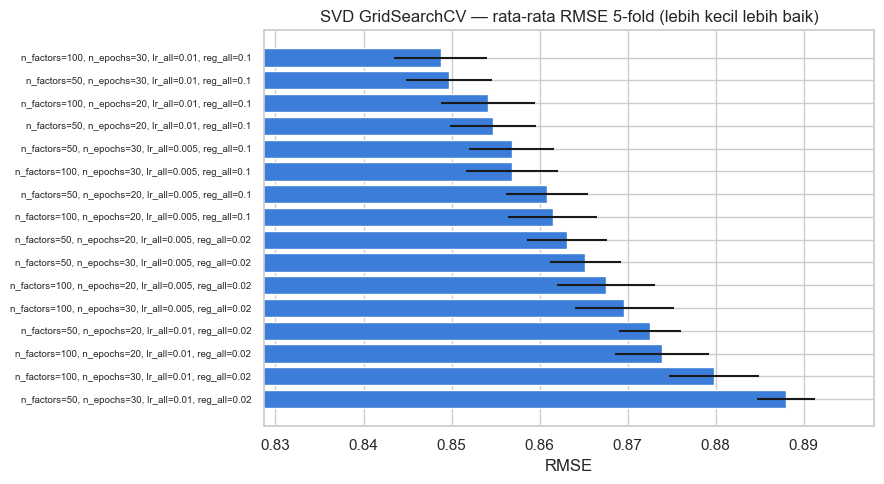

In [33]:
plot_svd_grid_search(cv_table, save_path=FIG_DIR / "10_svd_grid_search.png")
plt.show()

In [34]:
svd_model = SVD(random_state=SEED, **best_params)
svd_model.fit(train_surprise.build_full_trainset())

# Skor untuk seluruh pasangan user-film dihitung sekaligus dari faktor laten (vektorisasi).
trainset = svd_model.trainset
p_u = np.array([svd_model.pu[trainset.to_inner_uid(u)] for u in user_ids])
b_u = np.array([svd_model.bu[trainset.to_inner_uid(u)] for u in user_ids])
q_i = np.array([svd_model.qi[trainset.to_inner_iid(i)] for i in item_ids])
b_i = np.array([svd_model.bi[trainset.to_inner_iid(i)] for i in item_ids])
svd_scores = (trainset.global_mean + b_u[:, None] + b_i[None, :] + p_u @ q_i.T).astype(np.float32)

# Sanity check: hasil vektorisasi sama dengan svd_model.predict()
u0, i0 = SAMPLE_USER, int(item_ids[5])
assert abs(np.clip(svd_scores[user_to_idx[u0], item_to_idx[i0]], 0.5, 5) - svd_model.predict(u0, i0).est) < 1e-4

svd_top = top_n_from_scores(SAMPLE_USER, svd_scores[user_to_idx[SAMPLE_USER]], score_name="predicted_rating")
svd_top["predicted_rating"] = svd_top["predicted_rating"].clip(0.5, 5.0)
print(f"Top-{TOP_N} rekomendasi SVD untuk user {SAMPLE_USER}:")
display(svd_top)

Top-10 rekomendasi SVD untuk user 1:


,movieId,title,genres,predicted_rating
0,92535,Louis C.K.: Live at the Beacon Theater (2011),Comedy,5.0
1,89904,The Artist (2011),Comedy|Drama|Romance,5.0
2,6460,"Trial, The (Procès, Le) (1962)",Drama,5.0
3,951,His Girl Friday (1940),Comedy|Romance,5.0
4,158966,Captain Fantastic (2016),Drama,5.0
5,177593,"Three Billboards Outside Ebbing, Missouri (2017)",Crime|Drama,5.0
6,3030,Yojimbo (1961),Action|Adventure,5.0
7,318,"Shawshank Redemption, The (1994)",Crime|Drama,5.0
8,1147,When We Were Kings (1996),Documentary,5.0
9,7008,Last Tango in Paris (Ultimo tango a Parigi) (1...,Drama|Romance,5.0


### 5.3 Collaborative Filtering #2 — Neural Collaborative Filtering (NeuMF)

**NeuMF** (He et al., 2017) menggabungkan dua cabang:

* **GMF** (*Generalized Matrix Factorization*) — perkalian elemen demi elemen *embedding* user dan film (generalisasi MF).
* **MLP** — *embedding* user dan film (terpisah dari GMF) digabung lalu dilewatkan ke layer `256 → 128 → 64 → 32` (ReLU + Dropout 0.2) untuk menangkap interaksi non-linier.

Output kedua cabang digabung lalu diproyeksikan ke satu *logit*.

**Implicit feedback:** tujuan sistem adalah *meranking* film, bukan menebak angka rating. Karena itu setiap film yang pernah dirating user dianggap **positif (1)**, dan untuk setiap positif diambil **4 film acak yang belum pernah dirating** sebagai **negatif (0)**. *Negative sampling* diulang setiap epoch. Model dioptimasi dengan `BCEWithLogitsLoss` dan Adam (lr = 0.001, batch 2048).

**Early stopping:** 10% rating latih tiap user disisihkan sebagai validasi. Setiap epoch dihitung NDCG@10 validasi, dan bobot epoch terbaik disimpan (*patience* 5, maksimum 30 epoch).

In [35]:
class NeuMF(nn.Module):
    def __init__(self, n_users, n_items, emb_dim=64, layers=(256, 128, 64, 32), dropout=0.2):
        super().__init__()
        self.user_gmf = nn.Embedding(n_users, emb_dim)
        self.item_gmf = nn.Embedding(n_items, emb_dim)
        self.user_mlp = nn.Embedding(n_users, emb_dim)
        self.item_mlp = nn.Embedding(n_items, emb_dim)
        mlp, in_size = [], emb_dim * 2
        for out_size in layers:
            mlp += [nn.Linear(in_size, out_size), nn.ReLU(), nn.Dropout(dropout)]
            in_size = out_size
        self.mlp = nn.Sequential(*mlp)
        self.output = nn.Linear(in_size + emb_dim, 1)
        for emb in (self.user_gmf, self.item_gmf, self.user_mlp, self.item_mlp):
            nn.init.normal_(emb.weight, std=0.01)
        for m in self.mlp:
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)
        nn.init.kaiming_uniform_(self.output.weight, a=1, nonlinearity="sigmoid")
        nn.init.zeros_(self.output.bias)

    def forward(self, users, items):
        gmf = self.user_gmf(users) * self.item_gmf(items)
        mlp = self.mlp(torch.cat([self.user_mlp(users), self.item_mlp(items)], dim=-1))
        return self.output(torch.cat([gmf, mlp], dim=-1)).squeeze(-1)


model_preview = NeuMF(n_users, n_items)
print(model_preview)
print("Jumlah parameter:", f"{sum(p.numel() for p in model_preview.parameters()):,}")

NeuMF(
  (user_gmf): Embedding(602, 64)
  (item_gmf): Embedding(3643, 64)
  (user_mlp): Embedding(602, 64)
  (item_mlp): Embedding(3643, 64)
  (mlp): Sequential(
    (0): Linear(in_features=128, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=256, out_features=128, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=128, out_features=64, bias=True)
    (7): ReLU()
    (8): Dropout(p=0.2, inplace=False)
    (9): Linear(in_features=64, out_features=32, bias=True)
    (10): ReLU()
    (11): Dropout(p=0.2, inplace=False)
  )
  (output): Linear(in_features=96, out_features=1, bias=True)
)
Jumlah parameter: 619,713


Fungsi metrik ranking didefinisikan di sini karena dipakai untuk *early stopping* NeuMF dan evaluasi akhir (penjelasan rumus ada di bagian Evaluation).

In [36]:
def precision_at_k(recommended, relevant, k):
    return sum(1 for item in recommended[:k] if item in relevant) / k


def recall_at_k(recommended, relevant, k):
    return sum(1 for item in recommended[:k] if item in relevant) / len(relevant) if relevant else 0.0


def ndcg_at_k(recommended, relevant, k):
    if not relevant:
        return 0.0
    dcg = sum(1 / np.log2(rank + 2) for rank, item in enumerate(recommended[:k]) if item in relevant)
    idcg = sum(1 / np.log2(rank + 2) for rank in range(min(len(relevant), k)))
    return dcg / idcg


def evaluate_ranking(scores, known_df, target_df, k_values=K_VALUES, threshold=RELEVANCE_THRESHOLD):
    # Film yang sudah dirating di `known_df` disembunyikan; relevan = rating >= threshold di `target_df`.
    masked = scores.astype(np.float64, copy=True)
    masked[known_df["userId"].map(user_to_idx).to_numpy(), known_df["movieId"].map(item_to_idx).to_numpy()] = -np.inf
    liked = target_df[target_df["rating"] >= threshold]
    relevant = {u: set(g) for u, g in liked.groupby("userId")["movieId"]}
    users = sorted(relevant)
    k_max = max(k_values)
    sub = masked[[user_to_idx[u] for u in users]]
    part = np.argpartition(-sub, k_max - 1, axis=1)[:, :k_max]
    top = np.take_along_axis(part, np.argsort(-np.take_along_axis(sub, part, axis=1), axis=1, kind="stable"), axis=1)

    recs = [item_ids[top[r]].tolist() for r in range(len(users))]
    result = {}
    for k in k_values:
        result[f"Precision@{k}"] = np.mean([precision_at_k(recs[r], relevant[u], k) for r, u in enumerate(users)])
        result[f"Recall@{k}"] = np.mean([recall_at_k(recs[r], relevant[u], k) for r, u in enumerate(users)])
        result[f"NDCG@{k}"] = np.mean([ndcg_at_k(recs[r], relevant[u], k) for r, u in enumerate(users)])
    result["evaluated_users"] = len(users)
    result["Coverage@10"] = len(np.unique(top[:, :10])) / n_items
    return result

In [37]:
@torch.no_grad()
def ncf_score_all(model, batch_users=64):
    model.eval()
    all_items = torch.arange(n_items, device=DEVICE)
    out = np.empty((n_users, n_items), dtype=np.float32)
    for start in range(0, n_users, batch_users):
        users = torch.arange(start, min(start + batch_users, n_users), device=DEVICE)
        logits = model(users.repeat_interleave(n_items), all_items.repeat(len(users)))
        out[start:start + len(users)] = torch.sigmoid(logits).view(len(users), n_items).cpu().numpy()
    return out


def train_neumf(train_part, val_part, max_epochs=30, patience=5, num_negatives=4, batch_size=2048, lr=1e-3):
    torch.manual_seed(SEED)
    rng = np.random.default_rng(SEED)
    users = train_part["userId"].map(user_to_idx).to_numpy()
    items = train_part["movieId"].map(item_to_idx).to_numpy()
    positive_keys = np.unique(users * n_items + items)

    model = NeuMF(n_users, n_items).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.BCEWithLogitsLoss()
    history, best_ndcg, best_state, stale = [], -1.0, None, 0

    for epoch in range(1, max_epochs + 1):
        start = time.perf_counter()
        # Negative sampling: 4 film acak yang belum pernah dirating untuk setiap interaksi positif
        neg_users = np.repeat(users, num_negatives)
        neg_items = rng.integers(0, n_items, len(neg_users))
        clash = np.isin(neg_users * n_items + neg_items, positive_keys)
        while clash.any():
            neg_items[clash] = rng.integers(0, n_items, clash.sum())
            clash = np.isin(neg_users * n_items + neg_items, positive_keys)

        all_u = torch.as_tensor(np.concatenate([users, neg_users]), device=DEVICE)
        all_i = torch.as_tensor(np.concatenate([items, neg_items]), device=DEVICE)
        labels = torch.cat([torch.ones(len(users)), torch.zeros(len(neg_users))]).to(DEVICE)

        model.train()
        order = torch.randperm(len(labels), device=DEVICE)
        total = 0.0
        for b in range(0, len(order), batch_size):
            idx = order[b:b + batch_size]
            optimizer.zero_grad(set_to_none=True)
            loss = loss_fn(model(all_u[idx], all_i[idx]), labels[idx])
            loss.backward()
            optimizer.step()
            total += loss.item() * len(idx)

        val = evaluate_ranking(ncf_score_all(model), train_part, val_part, k_values=(10,))
        history.append({"epoch": epoch, "train_loss": total / len(order),
                        "val_ndcg@10": val["NDCG@10"], "val_recall@10": val["Recall@10"]})
        print(f"Epoch {epoch:02d} | loss {total / len(order):.4f} | val NDCG@10 {val['NDCG@10']:.4f} "
              f"| val Recall@10 {val['Recall@10']:.4f} | {time.perf_counter() - start:.1f}s")

        if val["NDCG@10"] > best_ndcg + 1e-4:
            best_ndcg, best_state, stale = val["NDCG@10"], copy.deepcopy(model.state_dict()), 0
        else:
            stale += 1
            if stale >= patience:
                print(f"Early stopping — tidak ada perbaikan selama {patience} epoch.")
                break

    model.load_state_dict(best_state)
    return model, pd.DataFrame(history)


ncf_fit_df, ncf_val_df = split_by_user(train_df, test_size=0.1)
start = time.perf_counter()
ncf_model, ncf_history = train_neumf(ncf_fit_df, ncf_val_df)
best_epoch = int(ncf_history.loc[ncf_history["val_ndcg@10"].idxmax(), "epoch"])
print(f"Pelatihan selesai dalam {time.perf_counter() - start:.1f} detik — epoch terbaik: {best_epoch}")

Epoch 01 | loss 0.4622 | val NDCG@10 0.0742 | val Recall@10 0.0857 | 1.5s
Epoch 02 | loss 0.4068 | val NDCG@10 0.0878 | val Recall@10 0.1032 | 1.2s
Epoch 03 | loss 0.3705 | val NDCG@10 0.1042 | val Recall@10 0.1345 | 1.1s
Epoch 04 | loss 0.3344 | val NDCG@10 0.1073 | val Recall@10 0.1484 | 1.0s
Epoch 05 | loss 0.3021 | val NDCG@10 0.1085 | val Recall@10 0.1434 | 0.9s
Epoch 06 | loss 0.2764 | val NDCG@10 0.1074 | val Recall@10 0.1447 | 0.9s
Epoch 07 | loss 0.2550 | val NDCG@10 0.1123 | val Recall@10 0.1464 | 0.8s
Epoch 08 | loss 0.2343 | val NDCG@10 0.1178 | val Recall@10 0.1430 | 0.8s
Epoch 09 | loss 0.2165 | val NDCG@10 0.1166 | val Recall@10 0.1408 | 0.8s
Epoch 10 | loss 0.1982 | val NDCG@10 0.1062 | val Recall@10 0.1368 | 0.8s
Epoch 11 | loss 0.1826 | val NDCG@10 0.1098 | val Recall@10 0.1430 | 0.9s
Epoch 12 | loss 0.1652 | val NDCG@10 0.1107 | val Recall@10 0.1465 | 0.8s
Epoch 13 | loss 0.1502 | val NDCG@10 0.1108 | val Recall@10 0.1409 | 0.8s
Early stopping — tidak ada perbaikan s

Fungsi visualisasi *learning curve* NeuMF:

In [38]:
def plot_training_history(history: pd.DataFrame, save_path: Path | str | None = None) -> plt.Figure:
    """Training loss and validation NDCG@10 / Recall@10 per epoch for NeuMF."""
    best_epoch = int(history.loc[history["val_ndcg@10"].idxmax(), "epoch"])
    fig, (ax_loss, ax_val) = plt.subplots(1, 2, figsize=(11, 4))
    ax_loss.plot(history["epoch"], history["train_loss"], marker="o", color="#264653")
    ax_loss.set(title="Training loss (BCE)", xlabel="Epoch", ylabel="Loss")
    ax_val.plot(history["epoch"], history["val_ndcg@10"], marker="o", label="NDCG@10")
    ax_val.plot(history["epoch"], history["val_recall@10"], marker="o", label="Recall@10")
    ax_val.axvline(best_epoch, color=ACCENT, ls="--", label=f"epoch terbaik = {best_epoch}")
    ax_val.set(title="Validasi NeuMF", xlabel="Epoch", ylabel="Skor")
    ax_val.legend()
    return _finish(fig, save_path)

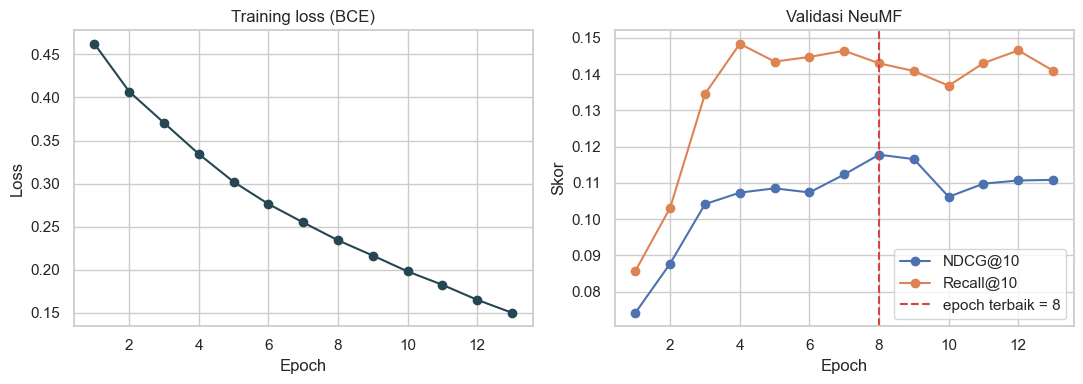

In [39]:
plot_training_history(ncf_history, save_path=FIG_DIR / "11_ncf_learning_curve.png")
plt.show()

**Insight:** *loss* latih terus turun, tetapi NDCG@10 validasi berhenti membaik setelah beberapa epoch — tanda model mulai *overfitting* pada interaksi latih. *Early stopping* mengembalikan bobot epoch dengan NDCG@10 validasi tertinggi.

In [40]:
ncf_scores = ncf_score_all(ncf_model)
print(f"Top-{TOP_N} rekomendasi NeuMF untuk user {SAMPLE_USER}:")
display(top_n_from_scores(SAMPLE_USER, ncf_scores[user_to_idx[SAMPLE_USER]], score_name="score"))

Top-10 rekomendasi NeuMF untuk user 1:


,movieId,title,genres,score
0,1391,Mars Attacks! (1996),Action|Comedy|Sci-Fi,0.9551
1,1573,Face/Off (1997),Action|Crime|Drama|Thriller,0.9122
2,1200,Aliens (1986),Action|Adventure|Horror|Sci-Fi,0.9121
3,380,True Lies (1994),Action|Adventure|Comedy|Romance|Thriller,0.9104
4,1036,Die Hard (1988),Action|Crime|Thriller,0.9006
5,2641,Superman II (1980),Action|Sci-Fi,0.8987
6,2716,Ghostbusters (a.k.a. Ghost Busters) (1984),Action|Comedy|Sci-Fi,0.8933
7,588,Aladdin (1992),Adventure|Animation|Children|Comedy|Musical,0.8923
8,2054,"Honey, I Shrunk the Kids (1989)",Adventure|Children|Comedy|Fantasy|Sci-Fi,0.8916
9,2174,Beetlejuice (1988),Comedy|Fantasy,0.8830


## 6. Evaluation

### 6.1 Metrik

**Metrik ranking** (tujuan utama: kualitas daftar *top-N*). Untuk setiap user, film di data uji dengan rating ≥ 4.0 adalah himpunan relevan $Rel$. Film yang sudah dirating di data latih dikeluarkan dari ranking. Nilai akhir adalah rata-rata semua user yang memiliki minimal satu film relevan.

* $\text{Precision@K} = \dfrac{|Rel \cap Rec@K|}{K}$ — proporsi rekomendasi yang tepat.
* $\text{Recall@K} = \dfrac{|Rel \cap Rec@K|}{|Rel|}$ — proporsi film relevan yang berhasil ditemukan.
* $\text{NDCG@K} = \dfrac{DCG@K}{IDCG@K}$, $\;DCG@K = \sum_{i=1}^{K} \dfrac{rel_i}{\log_2(i+1)}$ — memperhitungkan **posisi**: film relevan di peringkat atas bernilai lebih besar. IDCG adalah DCG untuk urutan ideal, sehingga NDCG bernilai 0–1.
* **Coverage@10** — proporsi katalog kandidat yang muncul minimal sekali di daftar top-10 seluruh user (keragaman).

**Metrik prediksi rating** (khusus SVD, yang memprediksi angka rating):

* $\text{RMSE} = \sqrt{\frac{1}{n}\sum (\hat r_i - r_i)^2}$ — menghukum galat besar lebih berat.
* $\text{MAE} = \frac{1}{n}\sum |\hat r_i - r_i|$ — rata-rata selisih absolut, dalam satuan bintang.

Sebagai pembanding, dihitung juga **popularity baseline** non-personal: semua user direkomendasikan film dengan jumlah rating ≥ 4.0 terbanyak di data latih.

In [41]:
def rmse(y_true, y_pred):
    return float(np.sqrt(np.mean((np.asarray(y_pred) - np.asarray(y_true)) ** 2)))


def mae(y_true, y_pred):
    return float(np.mean(np.abs(np.asarray(y_pred) - np.asarray(y_true))))


svd_test_pred = np.array([svd_model.predict(u, i).est for u, i in zip(test_df["userId"], test_df["movieId"])])
global_mean_pred = np.full(len(test_df), train_df["rating"].mean())

rating_table = pd.DataFrame(
    {
        "RMSE": [rmse(test_df["rating"], svd_test_pred), rmse(test_df["rating"], global_mean_pred)],
        "MAE": [mae(test_df["rating"], svd_test_pred), mae(test_df["rating"], global_mean_pred)],
    },
    index=["SVD (tuned)", "Global mean baseline"],
)
display(rating_table.round(4))

,RMSE,MAE
SVD (tuned),0.8410,0.6454
Global mean baseline,1.0281,0.8182


In [42]:
popular_counts = train_df[train_df["rating"] >= RELEVANCE_THRESHOLD]["movieId"].value_counts()
popularity_scores = np.tile(popular_counts.reindex(item_ids, fill_value=0).to_numpy(dtype=np.float32), (n_users, 1))

all_scores = {
    "Content-Based (TF-IDF)": cbf_scores,
    "CF — SVD": svd_scores,
    "CF — NeuMF": ncf_scores,
    "Popularity baseline": popularity_scores,
}
ranking_table = pd.DataFrame({name: evaluate_ranking(s, train_df, test_df) for name, s in all_scores.items()}).T
ranking_table["evaluated_users"] = ranking_table["evaluated_users"].astype(int)
ranking_table.to_csv(RESULT_DIR / "evaluation_metrics.csv")
display(ranking_table.round(4))

,Precision@5,Recall@5,NDCG@5,Precision@10,Recall@10,NDCG@10,evaluated_users,Coverage@10
Content-Based (TF-IDF),0.0328,0.0126,0.0391,0.0279,0.0222,0.0368,592,0.4661
CF — SVD,0.0155,0.0058,0.0166,0.0152,0.0125,0.0182,592,0.0571
CF — NeuMF,0.1970,0.0963,0.2174,0.1667,0.1604,0.2173,592,0.1691
Popularity baseline,0.1537,0.0668,0.1747,0.1248,0.1014,0.1653,592,0.0135


Fungsi visualisasi evaluasi:

In [43]:
def plot_metric_comparison(
    results: pd.DataFrame, save_path: Path | str | None = None
) -> plt.Figure:
    """Grouped bar chart of Precision / Recall / NDCG @K per model.

    Args:
        results: DataFrame indexed by model name; other columns (RMSE, coverage, ...)
            are ignored.
    """
    metrics = [c for c in results.columns if c.split("@")[0] in ("Precision", "Recall", "NDCG")]
    long = results[metrics].reset_index(names="model").melt(id_vars="model", var_name="metric")
    fig, ax = plt.subplots(figsize=(12, 5))
    sns.barplot(data=long, x="metric", y="value", hue="model", palette="Set2", ax=ax)
    for container in ax.containers:
        ax.bar_label(container, fmt="%.3f", fontsize=7, padding=1)
    ax.set(title="Perbandingan metrik ranking pada data uji", xlabel="", ylabel="Skor")
    ax.set_ylim(0, long["value"].max() * 1.12)
    ax.legend(title="", loc="upper center", bbox_to_anchor=(0.5, -0.08), ncol=4, frameon=False)
    return _finish(fig, save_path)


def plot_svd_errors(
    y_true: np.ndarray, y_pred: np.ndarray, save_path: Path | str | None = None
) -> plt.Figure:
    """Distribution of SVD prediction errors and MAE per actual rating value."""
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    errors = y_pred - y_true
    by_rating = (
        pd.DataFrame({"rating": y_true, "abs_err": np.abs(errors)})
        .groupby("rating")["abs_err"]
        .mean()
    )
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
    sns.histplot(errors, bins=40, kde=True, color="#3b7dd8", ax=ax1)
    ax1.axvline(0, color="black", lw=0.8)
    ax1.set(title="Distribusi galat prediksi SVD", xlabel="Prediksi − aktual")
    ax2.bar(by_rating.index.astype(str), by_rating.values, color="#e76f51")
    ax2.set(title="MAE SVD per nilai rating aktual", xlabel="Rating aktual", ylabel="MAE")
    return _finish(fig, save_path)

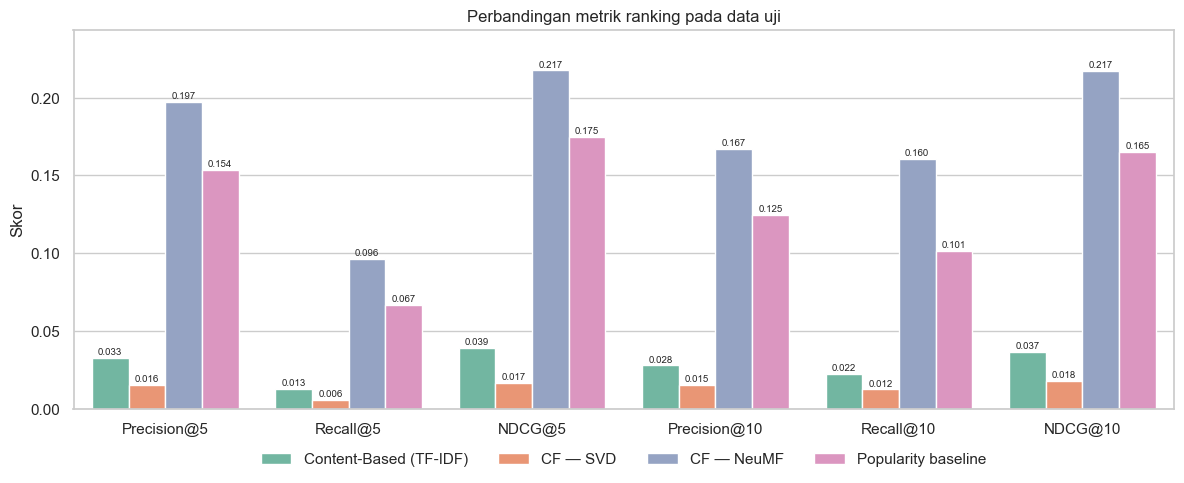

In [44]:
plot_metric_comparison(ranking_table, save_path=FIG_DIR / "12_metric_comparison.png")
plt.show()

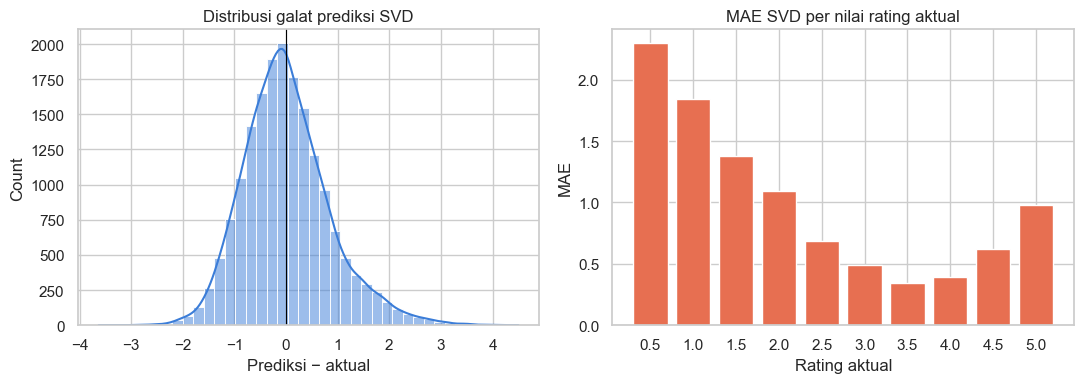

In [45]:
plot_svd_errors(test_df["rating"].to_numpy(), svd_test_pred, save_path=FIG_DIR / "13_svd_errors.png")
plt.show()

In [46]:
# Mengapa SVD rendah pada metrik ranking? Bandingkan popularitas film yang direkomendasikan.
train_popularity = train_df["movieId"].value_counts().reindex(item_ids, fill_value=0).to_numpy()


def median_popularity_of_top10(scores):
    masked = scores.astype(np.float64, copy=True)
    masked[train_u, train_i] = -np.inf
    top = np.argsort(-masked, axis=1)[:, :10]
    return float(np.median(train_popularity[top]))


popularity_view = pd.DataFrame(
    {"median jumlah rating latih pada film top-10": {n: median_popularity_of_top10(s) for n, s in all_scores.items()}}
)
popularity_view.loc["(median seluruh kandidat)"] = float(np.median(train_popularity))
display(popularity_view)

,median jumlah rating latih pada film top-10
Content-Based (TF-IDF),18.0
CF — SVD,9.0
CF — NeuMF,107.0
Popularity baseline,175.0
(median seluruh kandidat),10.0


### 6.2 Analisis hasil

* **NeuMF adalah model terbaik untuk tujuan top-N.** NeuMF unggul di semua metrik ranking (Precision@10, Recall@10, NDCG@10), termasuk atas *popularity baseline* yang sulit dikalahkan pada MovieLens. Model ini belajar langsung dari pola interaksi yang mirip dengan cara evaluasi dilakukan (film mana yang akan ditonton dan disukai), dan cakupan katalognya jauh lebih luas daripada baseline.
* **SVD paling baik untuk prediksi rating** — RMSE ±0.84 dan MAE ±0.65, jauh lebih baik dari prediksi rata-rata global. Namun metrik ranking SVD rendah: SVD dioptimasi untuk menebak angka rating pada film yang *sudah* ditonton. Saat meranking ribuan film yang belum ditonton, SVD memilih film yang jarang dirating tetapi berbias tinggi: median jumlah rating film top-10 SVD bahkan di bawah median seluruh kandidat, sedangkan NeuMF memilih film yang cukup dikenal namun tetap personal. Film yang jarang dirating juga jarang muncul di data uji.
* **Content-Based** lebih baik dari SVD pada ranking dan punya **coverage** tertinggi (rekomendasi beragam), tetapi kalah jauh dari NeuMF karena hanya memakai genre dan tag yang terbatas (±16% film ber-tag). Kelebihannya: tetap bisa merekomendasikan film baru tanpa rating dan hasil *item-to-item*-nya mudah dijelaskan (contoh *Toy Story* → *A Bug's Life*, *Toy Story 2*).
* Galat SVD terbesar ada pada rating ekstrem, terutama rating rendah 0.5–1.5 (MAE > 1.3) dan rating 5.0: model cenderung menarik prediksi ke arah rata-rata. Galat terkecil ada pada rating 3.5–4.0 yang paling sering muncul.

## 7. Kesimpulan

1. Data MovieLens (100.836 rating, 610 user, 9.742 film) sangat *sparse* (±98% kosong) dan berpola *long tail*. Filter *cold-start* dan pembagian 80:20 per user menghasilkan data latih dan uji yang representatif.
2. **Content-Based Filtering** (TF-IDF genre + tag dengan *weighted cosine similarity*) menghasilkan rekomendasi *item-to-item* yang relevan dan mudah dijelaskan, serta dapat menangani film baru.
3. **Collaborative Filtering SVD** yang di-*tuning* dengan GridSearchCV memberikan prediksi rating paling akurat (RMSE/MAE terendah).
4. **Collaborative Filtering NeuMF** dengan *implicit feedback* dan *negative sampling* memberikan kualitas daftar top-N terbaik (NDCG@10, Precision@10, Recall@10 tertinggi) dan dipilih sebagai model utama untuk fitur "rekomendasi untuk Anda".
5. Pengembangan selanjutnya: *hybrid* (CBF untuk film/user baru + NeuMF untuk user lama), penambahan metadata (sinopsis, pemeran) untuk memperkaya konten, dan evaluasi berbasis waktu (*temporal split*).